# M5 — Meta-learning & self-reference

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/foundations/m5-meta-learning-self-reference.ipynb)

**The question:** if a write is a learning step, can a network learn a good place to *start* those steps, or run them on itself?

Fifth module of the foundations spine. Runs on CPU in a couple of minutes; PyTorch throughout, plus a one-time ~10 MB Omniglot download (cached locally).

M4 gave the memory a built-in *learning rule*: the delta write is one SGD step per token (M4 §3). That opens two questions, and M5 answers both:

1. If a write is a learning step, can a network learn a **good starting point** so a *few* such steps adapt it to a brand-new task? → **meta-learning / MAML**.
2. The wild one: what if the matrix runs its delta rule on **its own weights**, generating the very keys, values and learning rates that modify itself? → the **self-referential weight matrix (SRWM)**.

Self-reference is the deepest root of Nested Learning's "levels": a single object that is at once program and data, optimizer and optimizee.

> **Prerequisite math** — *higher-order gradients* (`create_graph=True`; differentiating **through** a gradient step, which is the move that makes MAML's meta-gradient second-order) are built from scratch, with runnable demos, in the [backpropagation primer](../primers/backpropagation.ipynb) §6, §8.

## Objective

After this module you should be able to:

- State meta-learning as a **bilevel** problem: an **inner loop** that adapts to a task and an **outer loop** that learns *across* tasks: two timescales, the same nesting as M2's slow/fast split.
- Write **MAML**: inner $\theta'_i=\theta-\alpha\nabla_\theta\mathcal{L}_{T_i}(\theta)$, outer $\min_\theta\sum_i\mathcal{L}_{T_i}(\theta'_i)$ — *learn an initialization* from which a few gradient steps generalize.
- See why the meta-gradient is **second-order** (it differentiates *through* the inner gradient step) and what the first-order approximation drops.
- Write the **SRWM** update $W_t=W_{t-1}+\sigma(\beta_t)(\mathbf{v}_t-\bar{\mathbf{v}}_t)\otimes\varphi(\mathbf{k}_t)$ and explain how it **collapses the programmer/program split**: the same $W$ produces its own $\mathbf{k},\mathbf{q},\beta$ and reads its own $\bar{\mathbf{v}},\mathbf{v}$.
- Recognize SRWM as a strict generalization of M4's DeltaNet (untie the projections → recover the delta rule), and locate both on the road to [HOPE's self-modifying block](../tracks/nested-learning/nl3-hope.ipynb).

## Why it exists (the limitation it opens up)

M4's delta rule quietly changed what a "memory" is: each write is a **gradient-descent step** on a per-key regression loss. So the forward pass already runs an *inner optimization*. Two things were left implicit.

- **The starting point is arbitrary.** The memory begins at $\mathcal{M}_0=0$ and the slow weights begin random. If a write is a learning step, then *where you start* determines how many steps adaptation needs. Nothing so far *learns a good initialization* for fast adaptation. That's the gap MAML fills.
- **The programmer is frozen.** In M2–M4 a *slow* net (fixed within the forward pass) writes a *fast* memory. The slow net never adapts on the fly; the hierarchy programmer→program is rigid. What if the fast matrix could rewrite **its own** update rule? That's the gap SRWM fills.

Both are the same move, *making the learning process itself learnable*, applied at two depths: learn the **initial weights** (MAML), or learn a matrix that **modifies itself** (SRWM). Neither depth is new: "learning to learn" goes back to Schmidhuber's [1987 diploma thesis](https://people.idsia.ch/~juergen/diploma.html), and both papers below name it as their ancestor. What M4 changed is that you no longer have to *posit* an inner learner: the write already was one. This "learning to learn" is exactly the nesting that Nested Learning elevates to a first-class principle.

## Core idea — learning to learn, at two depths

**Meta-learning = two nested loops.** Sample a task $T_i$; the **inner loop** adapts parameters to it; the **outer loop** updates whatever the inner loop started from, so that adaptation works well *on average* over tasks:

$$\underbrace{\theta'_i=\theta-\alpha\nabla_\theta\mathcal{L}^{\text{support}}_{T_i}(\theta)}_{\text{inner: adapt to the task}}\qquad \underbrace{\min_\theta\ \textstyle\sum_i \mathcal{L}^{\text{query}}_{T_i}(\theta'_i)}_{\text{outer: learn the init across tasks}}$$

This is **MAML** ([Finn, Abbeel & Levine, 2017](https://arxiv.org/abs/1703.03400)): $\theta$ is not a solution to any task: it is a *launchpad* from which one or a few gradient steps reach a good task-specific $\theta'_i$. The outer update $\theta\leftarrow\theta-\eta\nabla_\theta\sum_i\mathcal{L}_{T_i}(\theta'_i)$ differentiates **through** the inner step, so it carries a second-order (Hessian) term, the "gradient through a gradient."

What MAML repaired is a *subtraction*: the meta-learners before it **learned the update rule itself**, a second network, with its own parameters, emitting the step. MAML keeps ordinary gradient descent and learns only *where it starts*, so it "does not expand the number of learned parameters nor place constraints on the model architecture" (§1). That is the whole of its model-agnosticism: the inner loop is already there in anything trained by gradient descent, and MAML only aims it.

**Self-reference = collapse the loops into one matrix.** M4's delta rule had a *separate* slow net invent $\mathbf{k},\mathbf{v},\mathbf{q},\beta$. The **SRWM** ([Irie, Schlag, Csordás & Schmidhuber, 2022](https://arxiv.org/abs/2202.05780)) lets one matrix $W$ do everything: it processes the input to emit its own modifier-key $\mathbf{k}_t$, analyzer-query $\mathbf{q}_t$, and learning rate $\beta_t$, queries *itself* for the current and target values, then **delta-updates itself**:

$$[\mathbf{y}_t,\mathbf{k}_t,\mathbf{q}_t,\beta_t]=W_{t-1}\varphi(\mathbf{x}_t),\quad \bar{\mathbf{v}}_t=W_{t-1}\varphi(\mathbf{k}_t),\quad \mathbf{v}_t=W_{t-1}\varphi(\mathbf{q}_t),\quad \boxed{\,W_t=W_{t-1}+\sigma(\beta_t)(\mathbf{v}_t-\bar{\mathbf{v}}_t)\otimes\varphi(\mathbf{k}_t)\,}$$

The programmer **is** the program. Set the producing-projections to a *separate, fixed* matrix and you are back at M4's DeltaNet; tie them to $W$ and the matrix learns to modify itself.

The design is a rebuild of a 90s idea. The paper "revisit[s] the self-referential WM ... from the '90s in the light of modern techniques" (§1): Schmidhuber's 1992–93 self-referential matrix, which addressed its own weights one at a time through a binary index. What the modern version swaps in is machinery you already have: the outer products and the delta rule of M4. The idea waited thirty years for its write rule.

### Reading

- **MAML**: [Finn et al. 2017, *Model-Agnostic Meta-Learning for Fast Adaptation of Deep Networks*](https://arxiv.org/abs/1703.03400): the inner/outer loops (§2.2), the second-order meta-gradient and what its first-order approximation drops (§5.2), and the sine-regression few-shot demo (§5.1, Figs. 2–3). Primary for the meta-learning half.
- **SRWM**: [Irie et al. 2022, *A Modern Self-Referential Weight Matrix That Learns to Modify Itself*](https://arxiv.org/abs/2202.05780): the self-referential update (§3, Eqs. 5–8, the boxed eq. above), the programmer/program collapse (§6, *Related Work*), and sequential task-switching (§4.2). Primary for the self-reference half.
- The *other* route to learning-to-learn (adapt **activations**, not weights): [RL²](https://arxiv.org/abs/1611.02779) (Duan et al., 2016) and [L2RL](https://arxiv.org/abs/1611.05763) (Wang et al., 2016): meta-learning that lives in an RNN's hidden state (in-context), no inner gradient. The two were posted eight days apart in November 2016 by different groups — one idea whose time had come. §4 puts the two routes side by side.

## 1. The bilevel loop and why the meta-gradient is second-order

The one subtlety that makes MAML *MAML* (and not just pretraining): the outer loss is a function of $\theta'_i$, which is itself a function of $\theta$ *through a gradient*. So $\nabla_\theta\mathcal{L}(\theta'_i)$ must differentiate through $\nabla_\theta\mathcal{L}^{\text{support}}(\theta)$ — a **Hessian** term. A minimal scalar task makes it concrete: task = "move $\theta$ toward $c$," loss $(\theta-c)^2$. The full meta-gradient keeps the $\tfrac{\partial\theta'}{\partial\theta}=1-2\alpha$ factor; the **first-order** approximation pretends that factor is 1.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

torch.manual_seed(0)
theta = torch.tensor(1.5, requires_grad=True)
c_support, c_query = 2.0, 2.0           # task: pull theta toward c (support adapts, query scores)
alpha = 0.3

# inner step, keeping the graph so we can backprop THROUGH it
inner_loss = (theta - c_support)**2
g_inner    = torch.autograd.grad(inner_loss, theta, create_graph=True)[0]
theta_prime = theta - alpha * g_inner
meta_loss  = (theta_prime - c_query)**2
g_full = torch.autograd.grad(meta_loss, theta)[0].item()        # second-order (through g_inner)

# first-order: treat theta' as if it didn't depend on theta via the inner gradient
tp_fo  = (theta - alpha*torch.autograd.grad((theta-c_support)**2, theta)[0]).detach().requires_grad_(True)
g_fo   = torch.autograd.grad((tp_fo - c_query)**2, tp_fo)[0].item()

print(f"theta'        = {theta_prime.item():.3f}   (one inner step from theta=1.5)")
print(f"meta-grad  second-order = {g_full:.3f}   (keeps d theta'/d theta = 1 - 2*alpha = {1-2*alpha:.1f})")
print(f"meta-grad  first-order  = {g_fo:.3f}   (pretends d theta'/d theta = 1)")
print("the gap IS the Hessian term: the outer loop differentiates through the inner gradient step.")

theta'        = 1.800   (one inner step from theta=1.5)
meta-grad  second-order = -0.160   (keeps d theta'/d theta = 1 - 2*alpha = 0.4)
meta-grad  first-order  = -0.400   (pretends d theta'/d theta = 1)
the gap IS the Hessian term: the outer loop differentiates through the inner gradient step.


::: {.callout-note collapse="true"}
## Q: Why did the inner loop use `torch.autograd.grad(...)` instead of `loss.backward()`?

Because MAML's inner step needs the gradient as a **value it can compute with** and keep **differentiable**, and `.backward()` gives neither. The two APIs do different jobs:

| | `loss.backward()` | `torch.autograd.grad(loss, params, create_graph=True)` |
|---|---|---|
| returns | `None` | the gradients, as a tuple of tensors |
| effect | accumulates into each leaf's `.grad` (a side-effect) | no side-effect; pure function |
| graph | grads stored as plain `.grad` slots | returned grads carry a `grad_fn` → differentiable again |

The inner loop is `θ' = θ - α·g`. That needs three things, all of which point to `autograd.grad`:

1. **A returned value.** We must *use* the gradient in an expression to build `θ'`. `autograd.grad` hands it back; `.backward()` returns `None` and you'd have to fish it out of `θ.grad`.
2. **Second-order differentiability.** The outer loss is evaluated at `θ'`, and we backprop through it *all the way to `θ`* — which means differentiating through `g` itself (the Hessian term this section is about). `create_graph=True` makes the returned `g` part of the graph, so that works.
3. **Functional, no global state.** MAML builds a chain of *new* parameter tensors `θ → θ' → θ'' …` that must stay graph-connected. `autograd.grad` composes cleanly; `.backward()` is built around mutating a *fixed* set of leaves in place (and accumulates, so you'd also have to zero `.grad` between inner steps). Wrong tool for a functional update.

**But notice the notebook uses both**, each where it fits. §2's meta-training cell shows the pair:

```python
grads = torch.autograd.grad(loss, p, create_graph=True)   # INNER: grad as a differentiable value
p = [pi - alpha*gi for pi, gi in zip(p, grads)]            #        build theta'
...
(ml / 4).backward(); opt.step()                            # OUTER: accumulate into meta-params' .grad,
                                                           #        then let Adam update them in place
```

The **outer** loop is an ordinary training step on the leaf meta-parameters, so `.backward()` + `optimizer.step()` is exactly right there. The **inner** loop is a functional, higher-order computation, so `autograd.grad` is the right tool. (You *can* force MAML through `.backward(create_graph=True)` by reading `θ.grad`, but you'd be managing accumulation and zeroing by hand — which is why `autograd.grad` is what `higher` / `learn2learn` / `torch.func` use under the hood.)
:::

## 2. MAML: a learned initialization that adapts in a few steps

Now the real thing, on the canonical task: **sine regression**. Each task is $f(x)=A\sin(x+\varphi)$ with random amplitude $A$ and phase $\varphi$; the model sees $K=10$ points and must fit the whole curve. We meta-train an MLP's initial weights so that **one** inner gradient step on the 10 support points generalizes. Then we test on a *new* sine: from the meta-init a few steps snap to the curve, while the same architecture from a random init barely moves.

(This is exactly MAML's Figs. 2–3: rapid adaptation within 1–10 gradient steps vs. a baseline init fine-tuned on the same task distribution.)

In [2]:
# --- a small functional MLP so we can take gradients w.r.t. params and step them manually ---
def init_params(sizes=(1, 40, 40, 1)):
    g = torch.Generator().manual_seed(0)
    ps = []
    for a, b in zip(sizes[:-1], sizes[1:]):
        w = (torch.randn(b, a, generator=g) * math.sqrt(2 / a)).requires_grad_(True)
        ps += [w, torch.zeros(b, requires_grad=True)]
    return ps


def fwd(params, x):
    h, n = x, len(params) // 2
    for i in range(n):
        h = h @ params[2 * i].t() + params[2 * i + 1]
        if i < n - 1:
            h = torch.tanh(h)
    return h


def adapt(params, x, y, alpha=0.01, steps=1, create_graph=True):
    p = params
    for _ in range(steps):
        loss = F.mse_loss(fwd(p, x), y)
        grads = torch.autograd.grad(loss, p, create_graph=create_graph)
        p = [pi - alpha * gi for pi, gi in zip(p, grads)]
    return p


def sample_task(g):
    A = torch.rand(1, generator=g) * 4.9 + 0.1
    phase = torch.rand(1, generator=g) * math.pi
    return lambda x: A * torch.sin(x + phase)


def shots(f, K, g):
    x = torch.rand(K, 1, generator=g) * 10 - 5
    return x, f(x)


# --- meta-train: learn theta so 1 inner step fits a task (second-order MAML) ---
meta = init_params()
opt = torch.optim.Adam(meta, lr=1e-3)
g = torch.Generator().manual_seed(1)
for it in range(3000):
    opt.zero_grad()
    ml = 0.0
    for _ in range(4):  # meta-batch of 4 tasks
        f = sample_task(g)
        xs, ys = shots(f, 10, g)  # support (adapt)
        xq, yq = shots(f, 10, g)  # query  (score)
        fast = adapt(meta, xs, ys, alpha=0.01, steps=1, create_graph=True)
        ml = ml + F.mse_loss(fwd(fast, xq), yq)
    (ml / 4).backward()
    opt.step()
print(f"meta-training done. final meta-loss = {(ml / 4).item():.3f}")

meta-training done. final meta-loss = 1.237


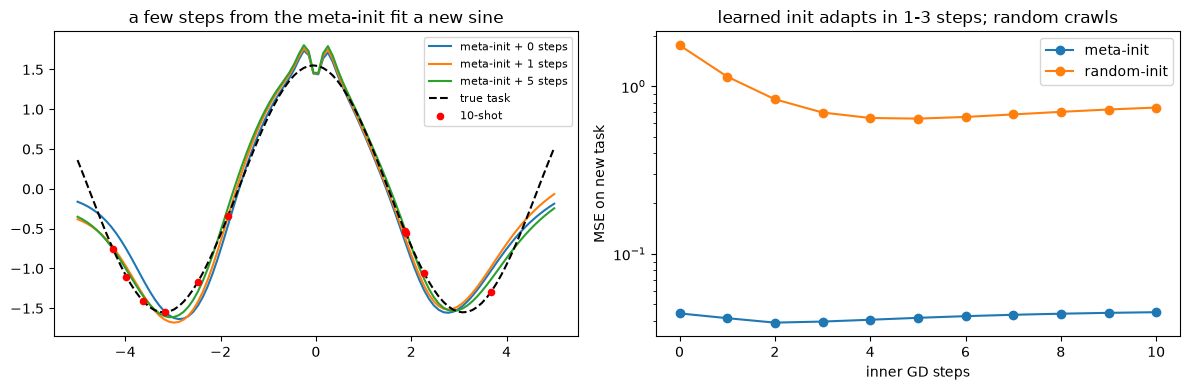

MAML learns WHERE to start so that gradient descent is fast -- a launchpad, not a solution.


In [3]:
# --- evaluate on a NEW task: meta-init vs random-init, as inner steps accumulate ---
gt = torch.Generator().manual_seed(123)
f  = sample_task(gt)
xs, ys = shots(f, 10, gt)
xx = torch.linspace(-5, 5, 100).reshape(-1, 1)
yy = f(xx)

def eval_after(base, steps):
    p = [pi.detach().clone().requires_grad_(True) for pi in base]
    p = adapt(p, xs, ys, alpha=0.01, steps=steps, create_graph=False)
    return p

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
for steps in (0, 1, 5):
    axL.plot(xx, fwd(eval_after(meta, steps), xx).detach(), label=f"meta-init + {steps} steps")
axL.plot(xx, yy, 'k--', label="true task"); axL.scatter(xs, ys, c='r', zorder=5, s=20, label="10-shot")
axL.set_title("a few steps from the meta-init fit a new sine"); axL.legend(fontsize=8)

rand = init_params_rand = [ (torch.randn_like(p)*0.3).requires_grad_(True) for p in meta ]
for name, base in [("meta-init", meta), ("random-init", rand)]:
    errs = [F.mse_loss(fwd(eval_after(base, s), xx), yy).item() for s in range(0, 11)]
    axR.plot(range(0, 11), errs, marker='o', label=name)
axR.set_yscale('log'); axR.set_xlabel("inner GD steps"); axR.set_ylabel("MSE on new task")
axR.set_title("learned init adapts in 1-3 steps; random crawls"); axR.legend()
plt.tight_layout(); plt.show()
print("MAML learns WHERE to start so that gradient descent is fast -- a launchpad, not a solution.")

## MAML for real — few-shot image classification (Omniglot)

The sine task isolates the *mechanics*; real meta-learning is **few-shot classification**: given a handful of labelled examples of *novel* classes, classify new instances of them. MAML's home benchmark is **Omniglot** ([Lake et al., 2011](https://web.mit.edu/jgross/Public/lake_etal_cogsci2011.pdf), the reference MAML itself cites): 1623 handwritten characters from 50 alphabets, 20 examples each ("the MNIST of meta-learning").

The protocol is **episodic, $N$-way $K$-shot**. Each episode samples $N$ new character classes, gives $K$ labelled *support* examples per class, and asks the model to classify $Q$ *query* examples. Meta-train and meta-test use **disjoint** characters, so at test time the model faces glyphs it has *never seen*. The **inner loop** adapts to the episode's $N$ classes; the **outer loop** learns an initialization from which that adaptation works on *any* set of characters, exactly the bilevel structure of §1–§2, now on real images.

We run **5-way 1-shot**: 5 novel characters, **one** labelled example each. The payoff to watch:

- from the meta-init, a *single* gradient step on those 5 examples classifies fresh samples of the same 5 characters;
- *before* adaptation the meta-init is at **chance** — it memorized no classes, it only learned a good launchpad;
- the *same* architecture from a random init can't catch up in a few steps.

(We reuse a small MLP for speed; the standard conv backbone reaches ~99% with the **same** algorithm, better features, identical mechanism. One-time ~10 MB Omniglot download, cached locally.)

downloading Omniglot (~10 MB, one time)...


Omniglot: (964, 20, 784) -> 800 meta-train classes, 164 NOVEL meta-test classes


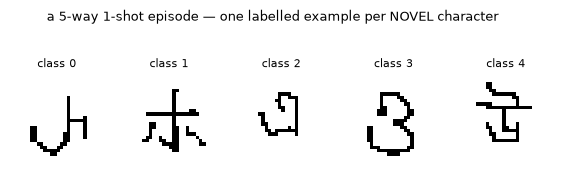

task: classify fresh handwritten samples of these 5 characters -- none seen during meta-training.


In [4]:
import os, urllib.request, zipfile
import numpy as np
import matplotlib.image as mpimg


def prepare_omniglot():
    """Download Omniglot once, cache as a 28x28 uint8 array. No torchvision needed."""
    root = os.path.expanduser("~/.cache/cl-course-data")
    os.makedirs(root, exist_ok=True)
    npy = os.path.join(root, "omniglot_bg_28.npy")
    if not os.path.exists(npy):
        zp = os.path.join(root, "images_background.zip")
        if not os.path.exists(zp):
            print("downloading Omniglot (~10 MB, one time)...")
            urllib.request.urlretrieve(
                "https://raw.githubusercontent.com/brendenlake/omniglot/master/python/images_background.zip", zp
            )
        with zipfile.ZipFile(zp) as z:
            z.extractall(root)
        base = os.path.join(root, "images_background")
        idx = np.linspace(0, 104, 28).astype(int)
        chars = []
        for alpha in sorted(os.listdir(base)):
            ap = os.path.join(base, alpha)
            if not os.path.isdir(ap):
                continue
            for ch in sorted(os.listdir(ap)):
                cp = os.path.join(ap, ch)
                if not os.path.isdir(cp):
                    continue
                ims = [
                    (1.0 - mpimg.imread(os.path.join(cp, f)))[idx][:, idx]  # invert (ink=1) + downsample
                    for f in sorted(os.listdir(cp))
                    if f.endswith(".png")
                ]
                if len(ims) == 20:
                    chars.append(np.stack(ims))
        np.save(npy, (np.stack(chars) * 255).astype(np.uint8))
    return np.load(npy).astype("float32") / 255.0  # [964 classes, 20 imgs, 28, 28], ink=1


data = torch.from_numpy(prepare_omniglot()).reshape(964, 20, 784)
perm = torch.randperm(964, generator=torch.Generator().manual_seed(0))
Xtr, Xte = data[perm[:800]], data[perm[800:]]  # DISJOINT meta-train / meta-test characters
print("Omniglot:", tuple(data.shape), "-> 800 meta-train classes, 164 NOVEL meta-test classes")


def episode(pool, N, K, Q, gen):  # one N-way K-shot episode
    cls = torch.randperm(pool.shape[0], generator=gen)[:N]
    xs, ys, xq, yq = [], [], [], []
    for i, c in enumerate(cls):
        o = torch.randperm(20, generator=gen)
        xs.append(pool[c, o[:K]])
        ys += [i] * K  # support
        xq.append(pool[c, o[K : K + Q]])
        yq += [i] * Q  # query
    return torch.cat(xs), torch.tensor(ys), torch.cat(xq), torch.tensor(yq)


# show a 5-way 1-shot support set: 5 novel characters, ONE labelled example each
xs, ys, xq, yq = episode(Xte, 5, 1, 5, torch.Generator().manual_seed(3))
fig, ax = plt.subplots(1, 5, figsize=(7, 1.8))
for i in range(5):
    ax[i].imshow(xs[i].reshape(28, 28), cmap="gray_r")
    ax[i].axis("off")
    ax[i].set_title(f"class {i}", fontsize=8)
fig.suptitle("a 5-way 1-shot episode — one labelled example per NOVEL character", y=1.12, fontsize=9)
plt.show()
print("task: classify fresh handwritten samples of these 5 characters -- none seen during meta-training.")

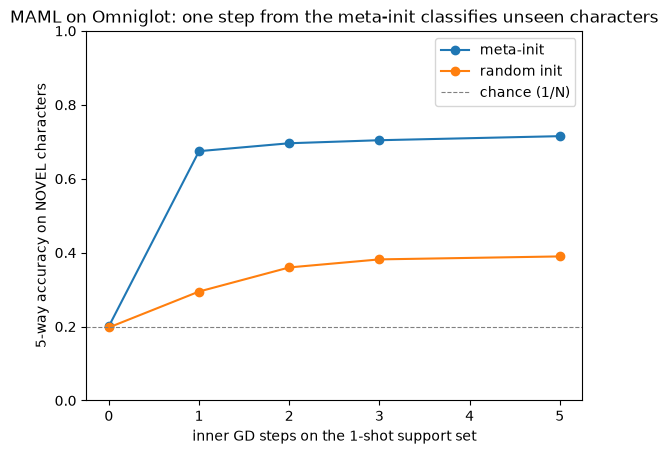

5-way 1-shot, NOVEL classes:  meta-init 20% before adapting (= chance 20%), 67% after ONE step.


random init reaches only 38% after 3 steps. The init is the whole story.
MLP backbone caps ~70%; a conv net reaches ~99% with the SAME algorithm -- better features, identical mechanism.


In [5]:
# classification MLP + a cross-entropy inner loop (same MAML as section 2, now N-way classification)
def mlp(p, x):
    h, n = x, len(p) // 2
    for i in range(n):
        h = h @ p[2 * i].t() + p[2 * i + 1]
        if i < n - 1:
            h = F.relu(h)
    return h


def adapt_ce(p, x, y, alpha, steps, create_graph):
    for _ in range(steps):
        grads = torch.autograd.grad(
            F.cross_entropy(mlp(p, x), y), p, create_graph=create_graph
        )
        p = [pi - alpha * gi for pi, gi in zip(p, grads)]
    return p


def init_cls(N, seed=0, sizes=(784, 128, 128)):
    g = torch.Generator().manual_seed(seed)
    ps = []
    dims = list(sizes) + [N]
    for a, b in zip(dims[:-1], dims[1:]):
        ps += [
            (torch.randn(b, a, generator=g) * math.sqrt(2 / a)).requires_grad_(True),
            torch.zeros(b, requires_grad=True),
        ]
    return ps


N, K, Q = 5, 1, 5
meta = init_cls(N)
opt = torch.optim.Adam(meta, lr=2e-3)
gen = torch.Generator().manual_seed(1)
for it in range(600):  # second-order MAML, ~7 s
    opt.zero_grad()
    ml = 0.0
    for _ in range(8):  # meta-batch of 8 episodes
        xs, ys, xq, yq = episode(Xtr, N, K, Q, gen)
        fast = adapt_ce(meta, xs, ys, alpha=0.4, steps=1, create_graph=True)
        ml = ml + F.cross_entropy(mlp(fast, xq), yq)
    (ml / 8).backward()
    opt.step()


def meta_test_acc(base, steps):  # accuracy on NOVEL (held-out) characters
    gt = torch.Generator().manual_seed(7)
    tot = 0.0
    for _ in range(200):
        xs, ys, xq, yq = episode(Xte, N, K, Q, gt)
        p = [pi.detach().clone().requires_grad_(True) for pi in base]
        p = adapt_ce(p, xs, ys, alpha=0.4, steps=steps, create_graph=False)
        tot += (mlp(p, xq).argmax(1) == yq).float().mean().item()
    return tot / 200


rand = [(torch.randn_like(p) * 0.1).requires_grad_(True) for p in meta]
axis = [0, 1, 2, 3, 5]
plt.plot(axis, [meta_test_acc(meta, s) for s in axis], marker="o", label="meta-init")
plt.plot(axis, [meta_test_acc(rand, s) for s in axis], marker="o", label="random init")
plt.axhline(1 / N, ls="--", c="gray", lw=0.8, label="chance (1/N)")
plt.xlabel("inner GD steps on the 1-shot support set")
plt.ylabel("5-way accuracy on NOVEL characters")
plt.title("MAML on Omniglot: one step from the meta-init classifies unseen characters")
plt.legend()
plt.ylim(0, 1)
plt.show()

print(
    f"5-way 1-shot, NOVEL classes:  meta-init {meta_test_acc(meta, 0):.0%} before adapting (= chance {1 / N:.0%}),"
    f" {meta_test_acc(meta, 1):.0%} after ONE step."
)
print(
    f"random init reaches only {meta_test_acc(rand, 3):.0%} after 3 steps. The init is the whole story."
)
print(
    "MLP backbone caps ~70%; a conv net reaches ~99% with the SAME algorithm -- better features, identical mechanism."
)

## 3. Self-reference: a matrix that modifies itself

MAML still keeps a clean split — meta-parameters (the init) are learned *offline*, task parameters *online*. The **SRWM** dissolves the split entirely. One matrix $W$ plays every role: it reads the input, emits its own control signals, and rewrites itself with the delta rule. The boxed update again, in code terms: $W_{t-1}$ maps $\varphi(\cdot)\in\mathbb{R}^{d}$ to the stacked output $[\mathbf{y},\mathbf{k},\mathbf{q},\beta]$, then:

$$\bar{\mathbf{v}}_t=W_{t-1}\varphi(\mathbf{k}_t)\ \text{(current)},\quad \mathbf{v}_t=W_{t-1}\varphi(\mathbf{q}_t)\ \text{(target)},\quad W_t=W_{t-1}+\sigma(\beta_t)(\mathbf{v}_t-\bar{\mathbf{v}}_t)\otimes\varphi(\mathbf{k}_t).$$

This is M4's delta write with one change: the projections that produce $\mathbf{k},\mathbf{q},\beta$ and the values are **$W$ itself**, not a separate frozen net. The cell runs an SRWM forward over a sequence, traces how much it rewrites itself per step, and checks the generalization claim: freezing a *separate* producer matrix reproduces a plain DeltaNet write.

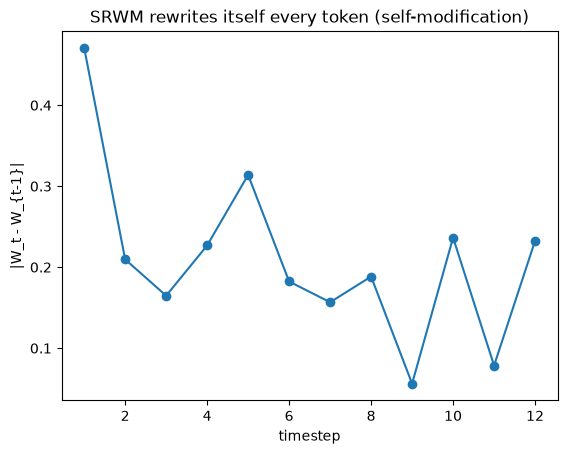

the SAME W produced k, q, beta and the values v, v_bar that then modified W. programmer == program.
untie the producer from W -> the update is exactly M4's delta write (DeltaNet); SRWM is its self-referential generalization.


In [6]:
torch.manual_seed(0)
d = 6
rows = 3 * d + 1  # output = [y(d), k(d), q(d), beta(1)]


def phi(z):
    return F.normalize(z, dim=-1)  # keep things bounded for the demo


W = torch.randn(rows, d) * 0.1  # the self-referential matrix (its own slow+fast)
seq = torch.randn(12, d)


def srwm_step(W, x):
    out = W @ phi(x)  # W emits output AND its own control signals
    y, k, q, beta = out[:d], out[d : 2 * d], out[2 * d : 3 * d], out[3 * d]
    v_bar = W @ phi(k)  # read CURRENT value at its own key   (in R^rows)
    v = W @ phi(q)  # read TARGET value via its own query (in R^rows)
    W_new = W + torch.sigmoid(beta) * torch.outer(v - v_bar, phi(k))  # delta-update ITSELF
    return W_new, y, (W_new - W).norm()


dW = []
for x in seq:
    W, y, step_norm = srwm_step(W, x)
    dW.append(step_norm.item())

plt.plot(range(1, 13), dW, marker="o")
plt.xlabel("timestep")
plt.ylabel("|W_t - W_{t-1}|")
plt.title("SRWM rewrites itself every token (self-modification)")
plt.show()
print("the SAME W produced k, q, beta and the values v, v_bar that then modified W. programmer == program.")

# Generalization check: a SEPARATE fixed producer + delta write == M4's DeltaNet (no self-reference).
torch.manual_seed(1)
Wmem = torch.zeros(d, d)  # the fast memory (M4's M)
Wprod = torch.randn(4, d, d) * 0.3  # FIXED slow net producing k,v,q,beta from x


def delta_step(M, x):
    k = phi(Wprod[0] @ x)
    q = phi(Wprod[1] @ x)
    v = Wprod[2] @ x
    beta = (Wprod[3] @ x).mean()
    v_bar = M @ k
    return M + torch.sigmoid(beta) * torch.outer(v - v_bar, k)


for x in seq:
    Wmem = delta_step(Wmem, x)
print(
    "untie the producer from W -> the update is exactly M4's delta write (DeltaNet); SRWM is its self-referential generalization."
)

## 4. Two timescales, two routes — and why this is "levels"

Step back and the pattern from M2 returns, now named. Every model in M2–M5 has **components that update at different rates**:

| | fast (inner) | slow (outer) |
|---|---|---|
| FWP / linear attn (M2–M3) | memory $\mathcal{M}$, per token | slow weights $W_\bullet$, per training step |
| DeltaNet (M4) | $\mathcal{M}$ via a learning *rule* | the rule's parameters |
| MAML | task params $\theta'_i$, per task | the init $\theta$, across tasks |
| SRWM | $W$ rewriting itself, per token | $W$'s trained structure, across training |

Order any system's memories by **how often they update** and you get a stack of timescales — *levels*. That single reframing is the seed of the [Continuum Memory System](../tracks/nested-learning/nl2-levels-continuum-memory.ipynb) and the whole Nested Learning thesis: optimizer, fast memory, and slow weights are not different *kinds* of thing, just *levels* of one nested learning process.

**Two routes to "learning to learn"**:

- **Adapt the weights** (this module): MAML takes explicit gradient steps; SRWM self-modifies. Adaptation lives in *parameters*.
- **Adapt the activations** (RL² / L2RL): an ordinary RNN, meta-trained, carries adaptation in its *hidden state*, "in-context learning," no inner gradient at all. Fast weights are the bridge: a memory matrix is "activations that behave like weights," so the two routes meet exactly at M2–M4's $\mathcal{M}$.

::: {.callout-note collapse="true"}
## Q: Why are meta-learning and self-reference in one notebook, and are they actually coupled?

Distinct ideas, but tightly coupled: they are **two mechanisms for the same goal**, *learning to learn* (fast adaptation), and the SRWM paper itself positions self-reference *as* a meta-learning approach, explicitly against MAML.

**First, they really are different axes** (you can have either without the other):

- **Meta-learning** is a *training paradigm*: learn across a distribution of tasks so that adaptation is fast. It has an explicit **bilevel** structure: inner loop adapts, outer loop learns what the inner loop starts from.
- **Self-reference** is an *architectural property*: one object modifies its own parameters during the forward pass, with no programmer/program split.
- MAML on a vanilla MLP is meta-learning with **zero** self-reference (an external outer loop edits the init; the MLP never touches itself). And an SRWM trained by plain SGD on one task still self-modifies. So the concepts are separable. The question is a fair one.

**Why they belong together anyway:**

1. **Same parent question, from M4.** M4 showed *a write is a gradient step*. Two follow-ups fall out immediately: *(a)* can we learn a good **starting point** for those steps? → MAML; *(b)* can the thing taking the steps be the thing **being stepped**? → SRWM. Both are "make the learning process itself learnable." M5 is the module *about that question*; MAML and SRWM are its two answers.

2. **SRWM is, in practice, a meta-learning method.** The [SRWM paper](https://arxiv.org/abs/2202.05780) meta-trains it on the *same* few-shot benchmarks as MAML, 5-way Omniglot and Mini-ImageNet (§4.1, Table 1: 47.0 ± 0.2% 1-shot Mini-ImageNet, level with DeltaNet and a shade under MAML's 48.7 ± 1.8), and positions itself against MAML on exactly the initialization axis (§4.1): *"MAML optimises the initial weights for future fine-tuning via gradient descent. In the SRWM, the initial weights also learn and encode its own self-modification algorithm."* The paper reads its own result the same way: *"our performance is respectable compared to that of MAML without requiring bi-level optimisation"* (§4.1). So self-reference here is **a way of doing meta-learning**, parity with MAML, minus the outer loop, not an unrelated topic that happens to share a module.

3. **They're two points on one spectrum: where does the bilevel structure live?**

   | | what adapts | bilevel structure |
   |---|---|---|
   | **MAML** | weights (explicit GD steps) | **explicit & external**: two optimization loops; meta-init frozen during adaptation |
   | **SRWM** | weights (self-modification) | **collapsed**: the inner loop *is* the forward-pass self-edit; the outer loop is plain SGD training the self-modifier |
   | RL² / in-context (above) | activations only | collapsed into hidden state; no inner gradient at all |

   MAML keeps the two levels apart; SRWM folds them into a single matrix that is its own meta-learner, the paper's own framing is that it *"collapse[s] these potentially hierarchical meta-levels into one single self-referential weight matrix"* (SRWM §6, *Related Work*), and RL² folds adaptation into activations. The same question, *how is adaptation realized*, differing along (what adapts) × (explicit vs collapsed hierarchy).

4. **The NL payoff: both are *nesting*.** A learning process inside a learning process is exactly the course's destination. Meta-learning makes the nesting **explicit** as two timescales (per-task vs across-task); self-reference is the **limit** where the levels collapse into one self-optimizing object. That's why the spine threads them as a single beat: M5 = "the nesting becomes the subject," feeding straight into the Nested Learning track, [test-time training](../tracks/nested-learning/nl1-test-time-learning.ipynb) (adaptation *in* the forward pass) and [levels](../tracks/nested-learning/nl2-levels-continuum-memory.ipynb) (order memories by update frequency).

They *could* be two modules, and splitting M5 into "M5a meta-learning / M5b self-reference" would cost nothing in the spine; I keep them together because the punchline, *self-reference is meta-learning with the meta/base hierarchy collapsed into one matrix*, lands hardest when you meet MAML's explicit bilevel loop first and then watch SRWM dissolve it.
:::

## Code walkthrough — meta-learning & SRWM in real code

- **MAML**: the reference implementations use the same pattern as §2: a functional forward, an inner `torch.autograd.grad(..., create_graph=True)` step, and an outer Adam update on the init. `first_order=True` simply drops `create_graph` (our §1 contrast). Libraries: [`higher`](https://github.com/facebookresearch/higher), [`learn2learn`](https://github.com/learnables/learn2learn), and `torch.func`.
- **SRWM**: the [paper's](https://arxiv.org/abs/2202.05780) layer is our `srwm_step` batched and multi-headed, with a custom CUDA kernel for the self-referential delta update; mathematically identical to the cell above ([§3, Eqs. 5–8](https://arxiv.org/abs/2202.05780)).
- **The community reproductions** wire self-modification into the full architecture: in [obekt/HOPE-nested-learning](https://github.com/obekt/HOPE-nested-learning), [`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py#L70) → `SelfModifyingLayer` is an SRWM-style block (the same `memory = a_t * memory + update` write, but the producer is part of the block), and [`titan/self_modifying.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/titan/self_modifying.py) in [kmccleary3301/nested_learning](https://github.com/kmccleary3301/nested_learning) isolates the mechanism as its own unit. These are the direct ancestors of [HOPE's self-modifying block](../tracks/nested-learning/nl3-hope.ipynb).

The one new ingredient over M4 is **tying the producer to the memory itself** (SRWM) or **backpropagating through an inner gradient step** (MAML) — both just *nesting one learning process inside another*, which autograd handles for free.

## Exit check

Self-test before M6: each question, then the answer we'd give.

**1. The inner/outer loops of MAML, and why $\theta$ is a launchpad not a solution.**
*Inner* adapts to one task by gradient descent on its support set: $\theta'_i=\theta-\alpha\nabla_\theta\mathcal{L}^{\text{sup}}_{T_i}(\theta)$. *Outer* optimizes the shared init across tasks so the *adapted* params do well on held-out queries: $\min_\theta\sum_i\mathcal{L}^{\text{qry}}_{T_i}(\theta'_i)$. $\theta$ minimizes loss *after* adaptation, not any single task's loss, so on its own it solves nothing, and the Omniglot demo showed it sitting at chance (20%) until one step adapts it. It's positioned for fast descent, i.e. a launchpad.

**2. Why the meta-gradient is second-order, and what first-order drops.**
The outer loss is evaluated at $\theta'_i$, which is itself $\theta$ minus a gradient. Differentiating $\mathcal{L}(\theta'_i)$ w.r.t. $\theta$ therefore passes through $\nabla_\theta\mathcal{L}^{\text{sup}}$, producing the Jacobian $\partial\theta'_i/\partial\theta = I-\alpha\nabla^2_\theta\mathcal{L}^{\text{sup}}$, a **Hessian**. First-order MAML (FOMAML) approximates that Jacobian as $I$, keeping only the query gradient at the adapted point and discarding the Hessian. §1 made the gap concrete: $-0.16$ (full) vs $-0.40$ (first-order), the difference being the $1-2\alpha$ factor.

**3. The SRWM update and the self-reference.**
$[\mathbf{y}_t,\mathbf{k}_t,\mathbf{q}_t,\beta_t]=W_{t-1}\varphi(\mathbf{x}_t)$, then $\bar{\mathbf{v}}_t=W_{t-1}\varphi(\mathbf{k}_t)$ (current), $\mathbf{v}_t=W_{t-1}\varphi(\mathbf{q}_t)$ (target), and $W_t=W_{t-1}+\sigma(\beta_t)(\mathbf{v}_t-\bar{\mathbf{v}}_t)\otimes\varphi(\mathbf{k}_t)$. The *same* $W_{t-1}$ both emits its control signals $\mathbf{k},\mathbf{q},\beta$ (first line) and supplies the values by querying itself (next two) — programmer = program. Replace those producing-projections with a *separate, fixed* slow net and the update is exactly M4's delta write: DeltaNet is SRWM with the producer untied from the memory.

**4. "Levels" as update frequency, and the two routes.**
A *level* is just a set of parameters/state grouped by **how often it updates**: fast inner memory (per token/per task) vs slow weights (per training step); NL treats optimizer, fast memory, and slow weights as levels of one nested process, not different kinds of thing. Two routes to learning-to-learn: **adapt the weights** (MAML's GD steps, SRWM's self-modification) vs **adapt the activations** (RL²/L2RL carry adaptation in an RNN's hidden state, in-context, no inner gradient).

**Next → M6, optimizers as associative memories.** M4 made one write a gradient step; M5 made the inner loop explicit (MAML) and self-referential (SRWM). M6 turns the same lens on the *other* additive write in every model you have ever trained: the optimizer, piling gradients onto a memory of the gradient stream, and applies M4's fix one level up.

Then the [Nested Learning track](../tracks/nested-learning/nl1-test-time-learning.ipynb) takes the limit in the other direction: let the memory be **a whole model trained at inference**, its write a *multi-step* gradient descent on a deeper objective. The hidden state stops being a matrix you add to and becomes a network you *train on the fly* — test-time training, Titans, Miras, Atlas.